In [19]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/../exp_pybamm.py'>

In [20]:
from neuralop.models import FNO

In [21]:
def gen_data_NO(batches):
    I = np.zeros((batches,1,1000))
    V = np.zeros((batches,1,1000))
    for i in trange(batches):
        _, _, I[i,0,:], V[i,0,:] = exp_pybamm.get_values()
    return I, V

In [22]:
#I_gen,V_gen = gen_data_NO(100)


In [23]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']

In [24]:


# np.savez('data_NO/I.npz',np.vstack((I,I_gen)))
# np.savez('data_NO/V.npz',np.vstack((V,V_gen)))

In [25]:
I = np.load('data_NO/I.npz')['arr_0']
V = np.load('data_NO/V.npz')['arr_0']



test_size = 0.1
I_test = I[0:int(test_size * len(I)),:,:]; V_test = V[0:int(test_size * len(I)),:,:]
I_train = I[int(test_size * len(I)):,:,:]; V_train = V[int(test_size * len(I)):,:,:]

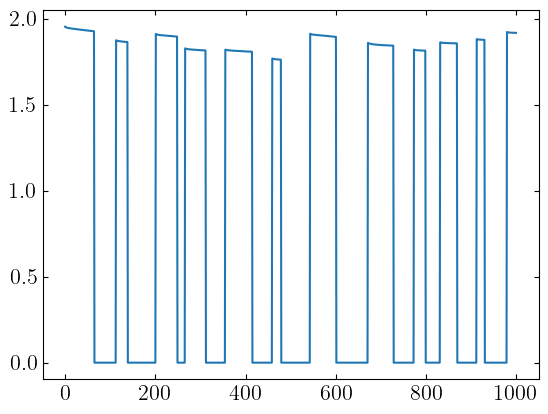

In [26]:
n = 14
plt.plot(I[n,0,:] * V[n,0,:])

In [27]:
from neuralop.models import FNO 
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         
    hidden_channels=32, 
    in_channels=1,      
    out_channels=1,     
)

In [28]:
# from torch.utils.data import DataLoader, TensorDataset

# N, T = 1024, 64

# u = np.zeros((N, T,1))
# y = np.zeros((N, T,1))
# for i in trange(N):
#     w = random.uniform(0.5, 2.0)
#     u[i,:,0] = np.sin(w * np.linspace(0, 3.14, T))
#     y[i,:,0] = w*np.cos(w * np.linspace(0, 3.14, T))


# print(u.shape, y.shape  )

# dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
#                         torch.tensor(y, dtype=torch.float32))

# loader = DataLoader(dataset, batch_size=32, shuffle=True)

# u_batch, y_batch = next(iter(loader))
# print(u_batch.shape)  # should be [32, 64, 1]


In [64]:
from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I, dtype=torch.float32), 
                        torch.tensor(V, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.HuberLoss()



torch.Size([32, 1, 1000])


In [65]:

# epochs = 50
# tol = 2.5e-4
# for epoch in range(epochs):
#     nb = 0 
#     loss_sum = 0
#     start_b = time.perf_counter()
#     for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
#         y_pred = model(u_batch)
#         loss = loss_fn(y_pred, y_batch)
#         loss_sum += loss.item()
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         nb += 1
#     end_b = time.perf_counter()
#     ETA = (end_b-start_b)*(epochs-epoch-1)
#     if loss_sum / nb < tol:
#         print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
#         break
#     print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    

In [66]:
# model = MyModel()
# loss_fn = nn.HuberLoss()

# x = x.requires_grad_(True)
# u_pred = model(x)

# # --- Data loss ---
# data_loss = loss_fn(u_pred, u_true)

# # --- Physics loss ---
# du_dx = torch.autograd.grad(
#     u_pred,
#     x,
#     grad_outputs=torch.ones_like(u_pred),
#     create_graph=True
# )[0]

# physics_residual = du_dx + u_pred
# physics_loss = torch.mean(physics_residual**2)

# # --- Total loss ---
# lambda_phys = 0.1
# loss = data_loss + lambda_phys * physics_loss

In [67]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    lambda_phys = 10
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
            y_pred = model(u_batch)
            data_loss = loss_fn(y_pred, y_batch)
            #physics_loss = physics_loss_fn(y_pred, u_batch) 
            loss = data_loss# + lambda_phys * physics_loss
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [68]:
model, history = training(epochs=10, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 0.0280 ETA: 0:30
Epoch 2 average loss: 0.0095 ETA: 0:25
Epoch 3 average loss: 0.0055 ETA: 0:22
Epoch 4 average loss: 0.0030 ETA: 0:19
Epoch 5 average loss: 0.0016 ETA: 0:17
Epoch 6 average loss: 0.0008 ETA: 0:12
Epoch 7 average loss: 0.0004 ETA: 0:09
Epoch 8 average loss: 0.0003 ETA: 0:06
Epoch 9 average loss: 0.0002 Time: 0:03 - Early stopping


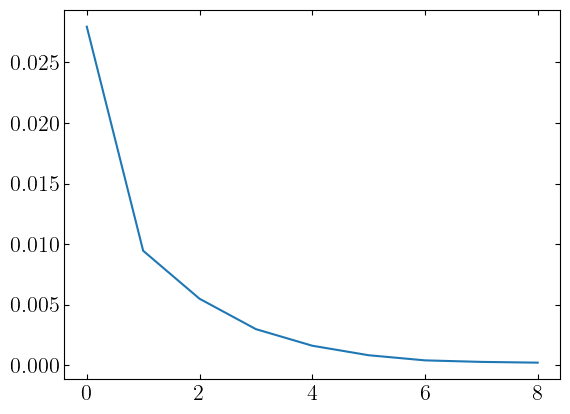

In [69]:
plt.plot(history['loss'])

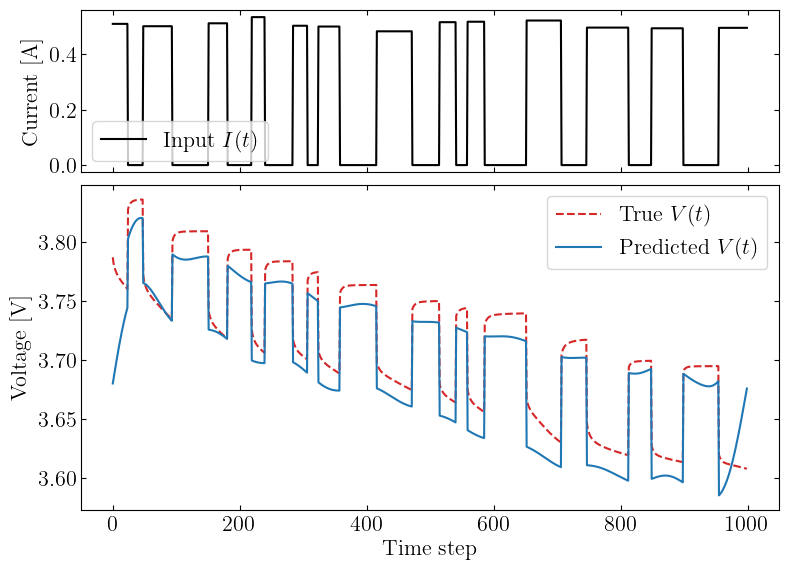

In [70]:
test = 17
i = I_test[test,0,:].reshape(1, 1, 1000) 
v = V_test[test,0,:].reshape(1, 1, 1000)

#print(i.shape, v.shape)
y_pred = model(torch.tensor(i, dtype=torch.float32))
f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)
f.subplots_adjust(hspace=0.05)

ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax[1].plot(y_pred[0,0,:].detach().numpy(), label='Predicted $V(t)$', color='tab:blue')
ax[1].legend()
ax[0].legend()
ax[1].set_xlabel('Time step')
ax[0].set_ylabel('Current [A]')
ax[1].set_ylabel('Voltage [V]')
#plt.savefig('figs_NO/FNO_pred.pdf', bbox_inches='tight')
plt.show()

In [71]:
T = 1000

u_test = np.zeros((1, 1,T))
y_test = np.zeros((1, 1,T))
w_test =  30# This is in the training range (0.5 to 2.0)

u_test[0,0,:] = np.sin(w_test * np.linspace(0, 3.14, T))  # w=1.5 is in the training range
y_test[0,0,:] = w_test * np.cos(w_test * np.linspace(0, 3.14, T))

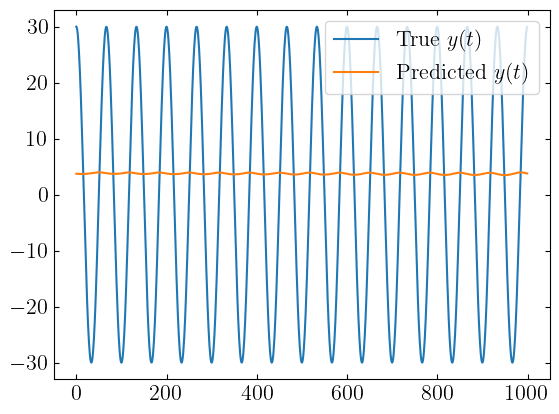

In [72]:
y_pred = model(torch.tensor(u_test, dtype=torch.float32))
plt.plot(y_test[0,0,:], label='True $y(t)$')
plt.plot(y_pred[0,0,:].detach().numpy(), label='Predicted $y(t)$')
plt.legend()
plt.show()